<a href="https://colab.research.google.com/github/juanadams362-NYC/SPAI/blob/feature%2Fbackend/model-training/SPAI_v2_eval.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install ultralytics -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.2/41.2 kB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 43.7 MB/s eta 0:00:00


In [2]:
!wget -q https://raw.githubusercontent.com/juanadams362-NYC/SPAI/feature/backend/model-training/runs/v2/weights/best.pt -O best.pt

In [3]:
import os
print(os.path.exists("best.pt"), os.path.getsize("best.pt") / 1e6, "MB")

True 6.244586 MB


In [4]:
from ultralytics import YOLO

model = YOLO("best.pt")
print(model.names)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
{0: 'glove', 1: 'hand'}


In [5]:
import glob
from ultralytics import YOLO

# grab every image in the current Colab folder
image_paths = glob.glob("/content/**/*.jpg", recursive=True) + glob.glob("/content/**/*.jpeg", recursive=True)
print(f"Found {len(image_paths)} images\n")

results = model.predict(image_paths, save=True, conf=0.25)

# log what was detected per image
for path, r in zip(image_paths, results):
    name = path.split("/")[-1]
    if len(r.boxes) == 0:
        print(f"{name:20s} → NO DETECTIONS")
    else:
        for box in r.boxes:
            cls = model.names[int(box.cls)]
            conf = float(box.conf)
            print(f"{name:20s} → {cls:6s} {conf:.2%}")

Found 4 images


0: 640x640 4 hands, 257.1ms
1: 640x640 (no detections), 257.1ms
2: 640x640 (no detections), 257.1ms
3: 640x640 (no detections), 257.1ms
Speed: 17.7ms preprocess, 257.1ms inference, 10.3ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/detect/predict
test-hand.jpg        → hand   86.20%
test-hand.jpg        → hand   85.28%
test-hand.jpg        → hand   83.40%
test-hand.jpg        → hand   76.28%
hand.jpg             → NO DETECTIONS
test-gloves1.jpeg    → NO DETECTIONS
test-gloves.jpeg     → NO DETECTIONS


image1.jpg


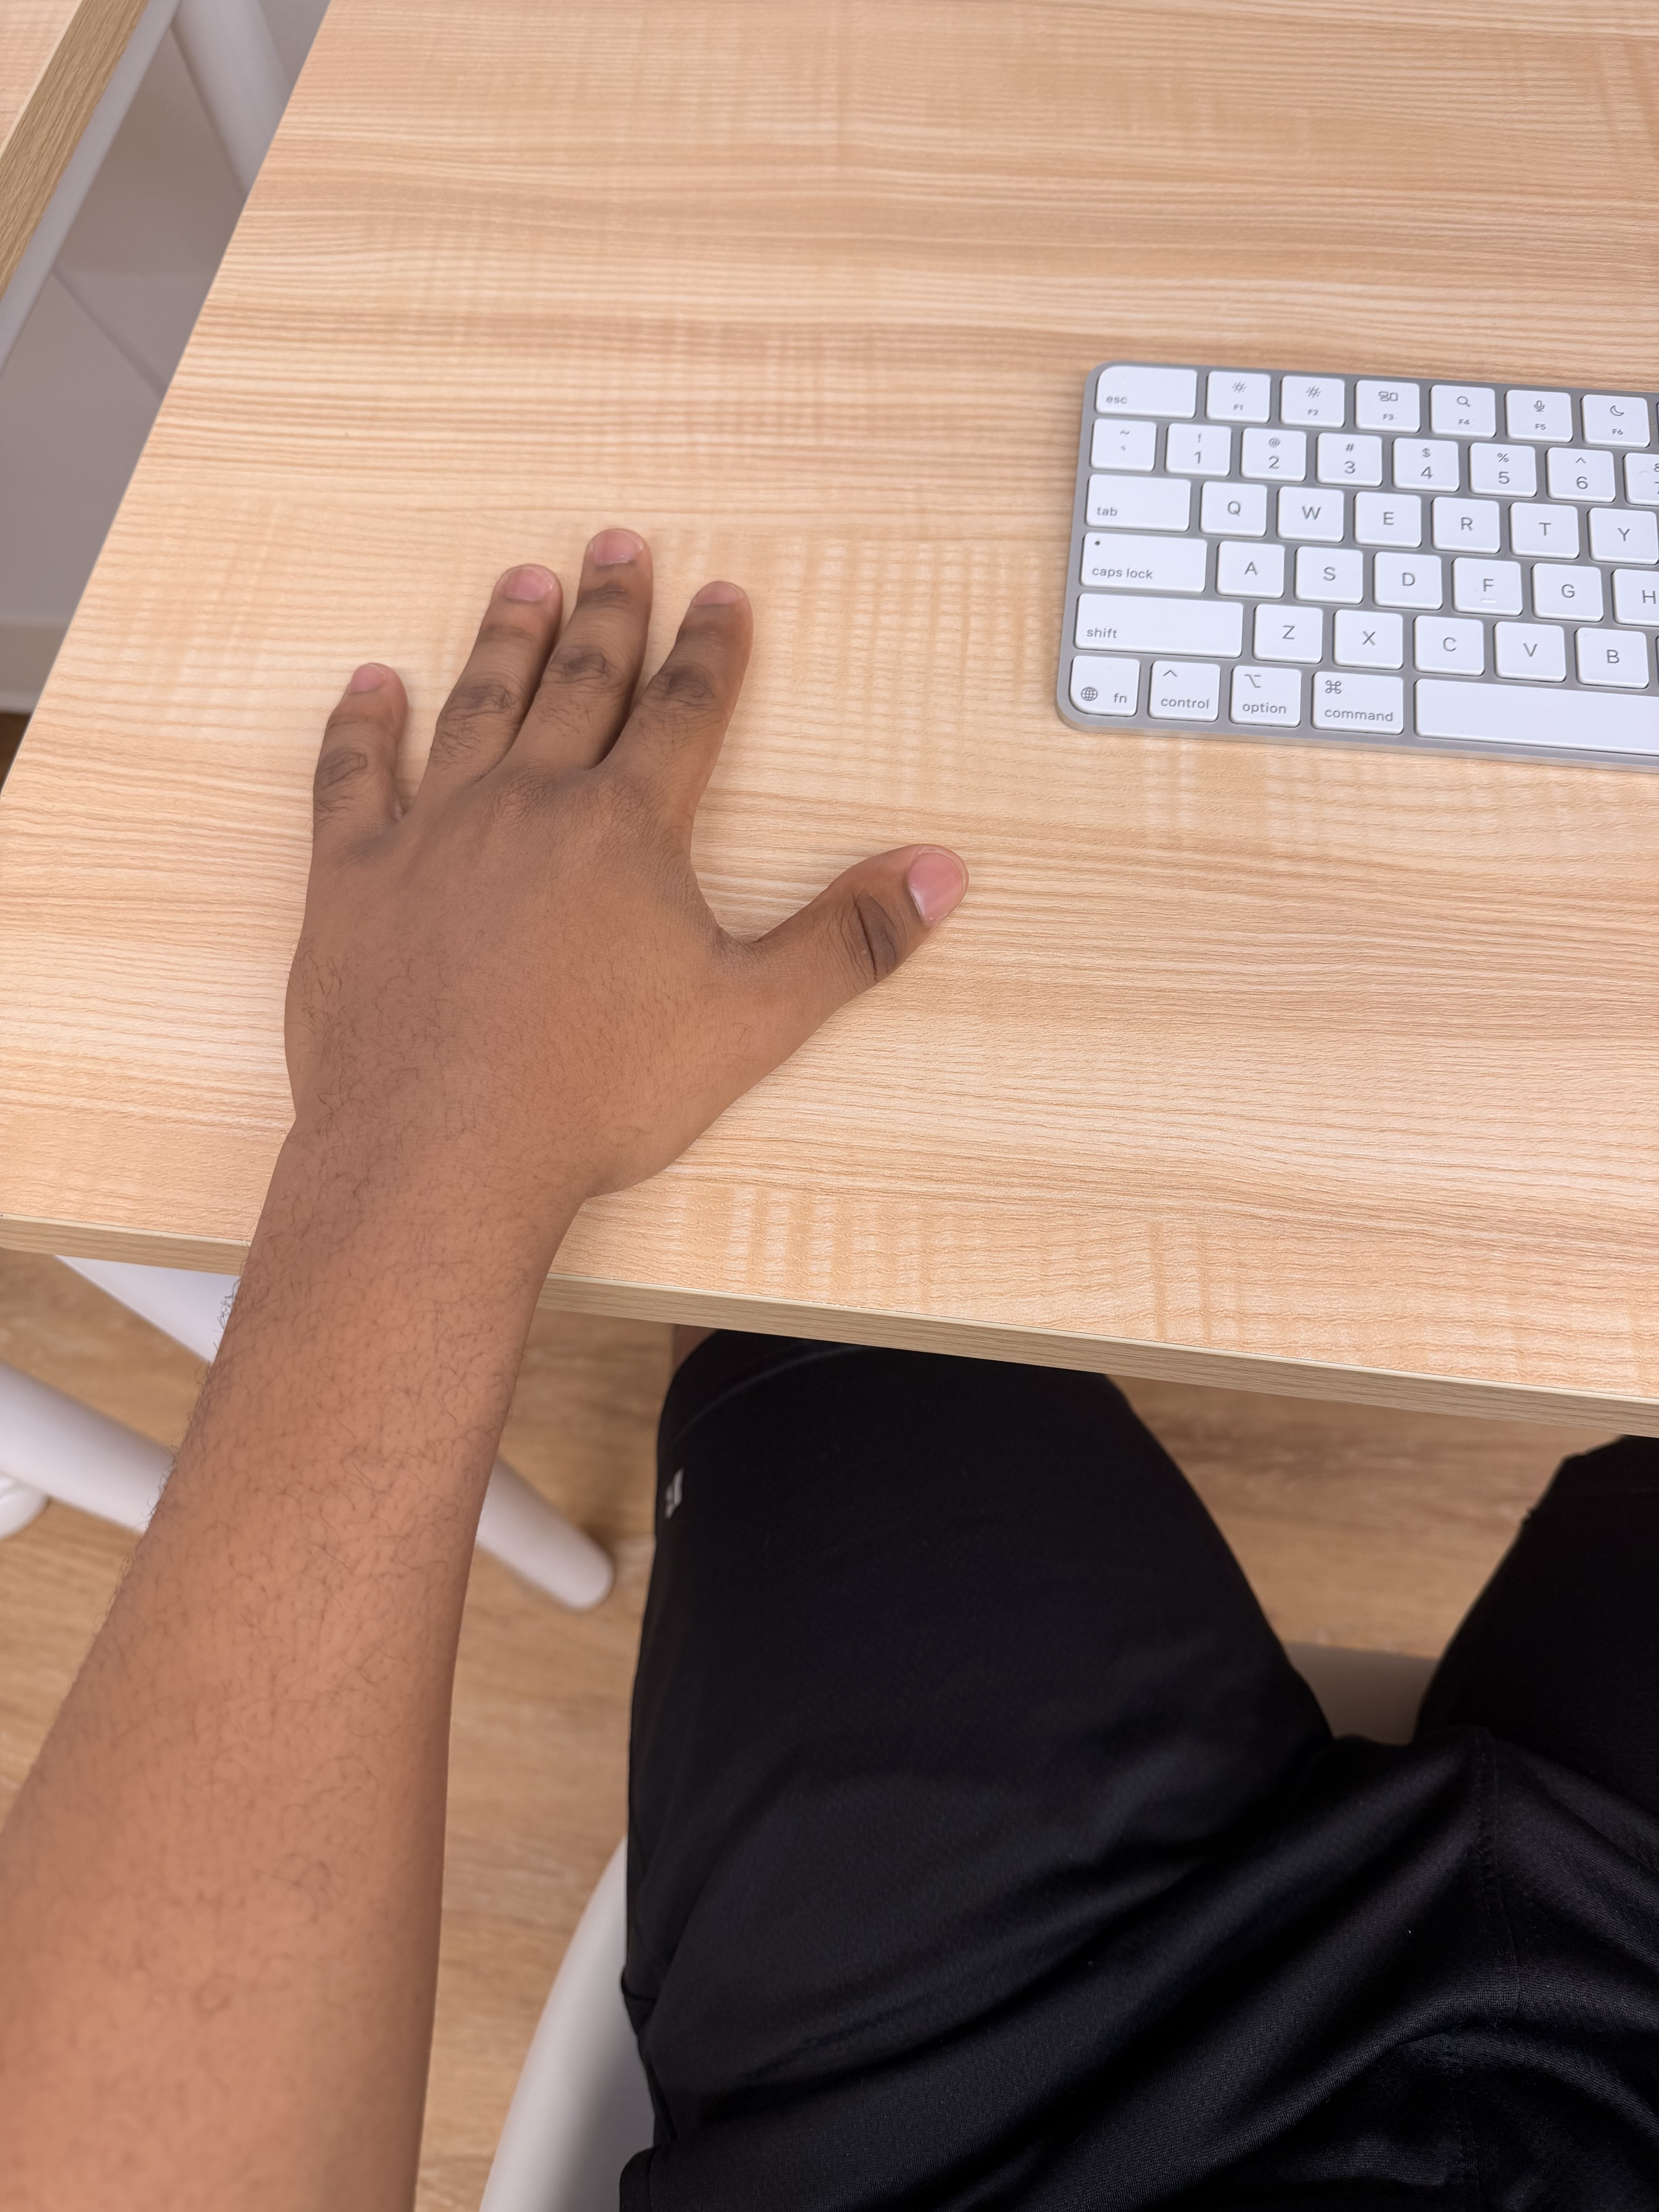

image3.jpg


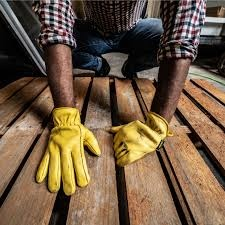

image0.jpg


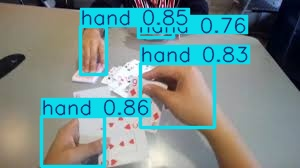

image2.jpg


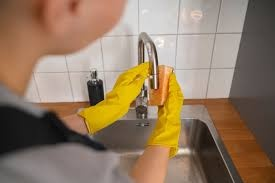

In [6]:
from IPython.display import Image, display
import glob

# the annotated copies YOLO saved (boxes drawn on)
annotated = glob.glob("/content/runs/detect/predict/*.jpg") + glob.glob("/content/runs/detect/predict/*.jpeg")

for path in annotated:
    print(path.split("/")[-1])
    display(Image(filename=path, width=400))

In [7]:
finding = """# SCRUM-53 — v2 Model Evaluation (Out-of-Distribution Probe)

**Date:** 2026-06-02 (Week 9)
**Model:** v2 `best.pt` (mAP50 0.936 on training distribution)
**Method:** Ran v2 inference at conf=0.25 on 4 web-sourced images outside the
training distribution. No formal held-out test set exists yet; this probe
deliberately targets OOD cases to characterize the distribution gap.

## Results

| Image | Subject | Result |
|-------|---------|--------|
| test-hand.jpg | hands playing cards (active, indoor) | 4 hands, 76-86% |
| hand.jpg | bare hand splayed flat on desk, top-down | no detection |
| test-gloves.jpeg | yellow leather work gloves | no detection |
| test-gloves1.jpeg | yellow rubber dish gloves | no detection |

## Findings

1. **In-distribution hands perform as expected.** The card image (EgoHands-like:
   curled, active, casual indoor) scored 76-86%, consistent with the 86%
   baseline. The model is sound on the data it was trained for.

2. **Gloves missed entirely (headline gap).** The `glove` class trained on
   industrial PPE; yellow leather/rubber differ in color and material and were
   not recognized. Confirms the known medical-nitrile domain gap — SPD blue/white
   nitrile is a further unseen appearance.

3. **Bare hand missed due to pose/framing, not just object type.** The splayed,
   top-down hand fell outside the trained pose distribution. Distribution is not
   only object class and color — pose and framing matter too.

## Implication for v3

Justifies SCRUM-62/63/64: source and label diverse data covering varied glove
colors and materials (incl. nitrile) and varied hand poses/framing, then retrain.

## Caveat

n=4, web-sourced. This is a qualitative gap probe, not a statistical benchmark.
A labeled held-out set remains future work for a true mAP comparison.
"""

import os
os.makedirs("/content/eval", exist_ok=True)
with open("/content/eval/SCRUM-53_v2_eval.md", "w") as f:
    f.write(finding)

print("Wrote eval/SCRUM-53_v2_eval.md")
print(finding)

Wrote eval/SCRUM-53_v2_eval.md
# SCRUM-53 — v2 Model Evaluation (Out-of-Distribution Probe)

**Date:** 2026-06-02 (Week 9)
**Model:** v2 `best.pt` (mAP50 0.936 on training distribution)
**Method:** Ran v2 inference at conf=0.25 on 4 web-sourced images outside the
training distribution. No formal held-out test set exists yet; this probe
deliberately targets OOD cases to characterize the distribution gap.

## Results

| Image | Subject | Result |
|-------|---------|--------|
| test-hand.jpg | hands playing cards (active, indoor) | 4 hands, 76-86% |
| hand.jpg | bare hand splayed flat on desk, top-down | no detection |
| test-gloves.jpeg | yellow leather work gloves | no detection |
| test-gloves1.jpeg | yellow rubber dish gloves | no detection |

## Findings

1. **In-distribution hands perform as expected.** The card image (EgoHands-like:
   curled, active, casual indoor) scored 76-86%, consistent with the 86%
   baseline. The model is sound on the data it was trained for.

2. **Gloves m